In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def plot_influence_field(
    nx=80,
    ny=80,
    nz=80,
    slice_y_index=None,
    random_seed=42
):
    """
    Conceptual visualization of a 3D human influence field in a sediment block.

    Left: 3D isometric cutaway (front half removed) with a hot central core
    Right: 2D vertical slice (x vs time/depth) through the same field
    """

    rng = np.random.default_rng(random_seed)

    # -------------------------------------------------
    # 1. Construct the 3D human-influence intensity field
    # -------------------------------------------------
    x = np.linspace(-1.0, 1.0, nx)
    y = np.linspace(-1.0, 1.0, ny)
    z = np.linspace(0.0, 1.0, nz)

    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

    # Main occupation blob:
    # - gaussian in time, peaked in the middle
    # - footprint slightly wider around the peak
    temporal = np.exp(-0.5 * ((Z - 0.5) / 0.18) ** 2)  # strong mid peak
    sigma_xy = 0.25 + 0.15 * np.exp(-0.5 * ((Z - 0.5) / 0.2) ** 2)

    r2 = X**2 + Y**2
    main_blob = np.exp(-r2 / (2.0 * sigma_xy**2)) * temporal

    # Small late hotspots near the top (do NOT dominate the core)
    def hotspot(x0, y0, z0, spread_xy=0.08, spread_z=0.05, amplitude=0.3):
        return amplitude * np.exp(
            -((X - x0) ** 2 + (Y - y0) ** 2) / (2 * spread_xy**2)
            -((Z - z0) ** 2) / (2 * spread_z**2)
        )

    frag1 = hotspot(0.4,  0.2, 0.8,  amplitude=0.3)
    frag2 = hotspot(-0.3, -0.4, 0.85, amplitude=0.25)

    influence = main_blob + frag1 + frag2

    # Mild noise for texture (can set to 0 if you want it ultra-clean)
    noise = 0.01 * rng.normal(size=influence.shape)
    influence = np.clip(influence + noise, 0.0, None)

    # Normalize to [0, 1]
    influence -= influence.min()
    if influence.max() > 0:
        influence /= influence.max()

    # Custom colormap: magma with 0 mapped to white
    base_cmap = plt.cm.magma
    colors = base_cmap(np.linspace(0, 1, 256))
    colors[0, :] = np.array([1, 1, 1, 1])  # white at zero
    white_magma = ListedColormap(colors)

    # -------------------------------------------------
    # 2. Create figure with 3D + 2D panels
    # -------------------------------------------------
    fig = plt.figure(figsize=(10, 4))
    ax3d = fig.add_subplot(1, 2, 1, projection="3d")
    ax2d = fig.add_subplot(1, 2, 2)

    if slice_y_index is None:
        slice_y_index = ny // 2
    y_slice = y[slice_y_index]

    # -------------------------------------------------
    # 3. 3D isometric cutaway
    # -------------------------------------------------

    # Cutaway: keep only points on and behind the slice plane (Y <= y_slice)
    mask = (Y <= y_slice) & (influence > 0.05)  # drop very low-intensity fog

    xs = X[mask]
    ys = Y[mask]
    zs = Z[mask]
    vals = influence[mask]

    # Optional subsampling so scatter isn't insane
    if xs.size > 40000:
        idx = rng.choice(xs.size, 40000, replace=False)
        xs, ys, zs, vals = xs[idx], ys[idx], zs[idx], vals[idx]

    # Sort by intensity so hot points are drawn last (on top)
    order = np.argsort(vals)
    xs, ys, zs, vals = xs[order], ys[order], zs[order], vals[order]

    # Nonlinear mapping to brighten the mid-range
    vals_color = vals ** 0.8  # < 1 brightens medium values

    colors_rgba = white_magma(vals_color)
    # Alpha: hotter = more opaque
    colors_rgba[:, 3] = 0.2 + 0.7 * vals

    ax3d.scatter(xs, ys, zs, c=colors_rgba, s=8, edgecolors="none")

    # Slice plane as semi-transparent surface
    Xp, Zp = np.meshgrid(x, z, indexing="ij")
    Yp = np.full_like(Xp, y_slice)
    ax3d.plot_surface(
        Xp, Yp, Zp,
        color="lightgrey",
        alpha=0.25,
        rstride=1,
        cstride=1,
        linewidth=0,
        antialiased=False,
        zorder=0,
    )

    ax3d.set_xlabel("horizontal space (x)")
    ax3d.set_ylabel("horizontal space (y)")
    ax3d.set_zlabel("time / depth")
    ax3d.set_xticks([]); ax3d.set_yticks([]); ax3d.set_zticks([])
    ax3d.set_title("3D human influence field (cutaway)")
    ax3d.view_init(elev=25, azim=135)

    # -------------------------------------------------
    # 4. 2D vertical slice
    # -------------------------------------------------
    slice_field = influence[:, slice_y_index, :]  # (nx, nz)

    # Rescale within slice to emphasise core, with soft edges
    s_lo, s_hi = np.percentile(slice_field, [10, 99])
    slice_norm = np.clip((slice_field - s_lo) / (s_hi - s_lo), 0.0, 1.0)

    rgba = white_magma(slice_norm)
    alpha_map = 0.15 + 0.85 * (slice_norm ** 1.3)
    rgba[..., 3] = alpha_map

    extent = [x.min(), x.max(), z.max(), z.min()]  # invert vertically

    im = ax2d.imshow(
        rgba,
        extent=extent,
        aspect="auto",
        origin="upper",
        interpolation="bilinear",
    )

    ax2d.set_xlabel("horizontal space (x)")
    ax2d.set_ylabel("time / depth")
    ax2d.set_xticks([]); ax2d.set_yticks([])
    ax2d.set_title("Vertical slice through sediment profile")

    # Colorbar keyed to [0,1] intensity scale
    norm = plt.Normalize(vmin=0.0, vmax=1.0)
    sm = ScalarMappable(norm=norm, cmap=white_magma)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax2d, shrink=0.8)
    cbar.set_label("human influence intensity")

    plt.tight_layout()
    plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def plot_influence_field(
    nx=80,
    ny=80,
    nz=80,
    slice_y_index=None,
    random_seed=42
):
    """
    Conceptual visualization of a 3D human influence field in a sediment block.

    Left: 3D isometric cutaway (front half removed) with a hot central core.
    Right: 2D vertical slice (x vs time/depth) through the same field,
           annotated with settlement diameter and core locations.
    """

    rng = np.random.default_rng(random_seed)

    # -------------------------------------------------
    # 1. Construct the 3D human-influence intensity field
    # -------------------------------------------------
    x = np.linspace(-1.0, 1.0, nx)
    y = np.linspace(-1.0, 1.0, ny)
    z = np.linspace(0.0, 1.0, nz)

    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

    # Main occupation blob:
    # - gaussian in time, peaked in the middle
    # - footprint slightly wider around the peak
    temporal = np.exp(-0.5 * ((Z - 0.5) / 0.18) ** 2)  # strong mid peak
    sigma_xy = 0.25 + 0.15 * np.exp(-0.5 * ((Z - 0.5) / 0.2) ** 2)

    r2 = X**2 + Y**2
    main_blob = np.exp(-r2 / (2.0 * sigma_xy**2)) * temporal

    # Small late hotspots near the top (do NOT dominate the core)
    def hotspot(x0, y0, z0, spread_xy=0.08, spread_z=0.05, amplitude=0.3):
        return amplitude * np.exp(
            -((X - x0) ** 2 + (Y - y0) ** 2) / (2 * spread_xy**2)
            -((Z - z0) ** 2) / (2 * spread_z**2)
        )

    frag1 = hotspot(0.4,  0.2, 0.8,  amplitude=0.3)
    frag2 = hotspot(-0.3, -0.4, 0.85, amplitude=0.25)

    influence = main_blob + frag1 + frag2

    # Mild noise for texture (can set to 0 if you want it ultra-clean)
    noise = 0.01 * rng.normal(size=influence.shape)
    influence = np.clip(influence + noise, 0.0, None)

    # Normalize to [0, 1]
    influence -= influence.min()
    if influence.max() > 0:
        influence /= influence.max()

    # Custom colormap: magma with 0 mapped to white
    base_cmap = plt.cm.magma
    colors = base_cmap(np.linspace(0, 1, 256))
    colors[0, :] = np.array([1, 1, 1, 1])  # white at zero
    white_magma = ListedColormap(colors)

    # -------------------------------------------------
    # 2. Figure and axes
    # -------------------------------------------------
    fig = plt.figure(figsize=(10, 4))
    ax3d = fig.add_subplot(1, 2, 1, projection="3d")
    ax2d = fig.add_subplot(1, 2, 2)

    if slice_y_index is None:
        slice_y_index = ny // 2
    y_slice = y[slice_y_index]

    # Choose core x-locations (conceptual)
    core_xs = [-0.6, -0.2, 0.3, 0.7]

    # -------------------------------------------------
    # 3. 3D isometric cutaway
    # -------------------------------------------------

    # Cutaway: keep only points on and behind the slice plane (Y <= y_slice)
    mask = (Y <= y_slice) & (influence > 0.05)  # drop very low-intensity fog

    xs = X[mask]
    ys = Y[mask]
    zs = Z[mask]
    vals = influence[mask]

    # Subsample so scatter isn't insane
    if xs.size > 40000:
        idx = rng.choice(xs.size, 40000, replace=False)
        xs, ys, zs, vals = xs[idx], ys[idx], zs[idx], vals[idx]

    # Sort by intensity so hot points are drawn last (on top)
    order = np.argsort(vals)
    xs, ys, zs, vals = xs[order], ys[order], zs[order], vals[order]

    # Nonlinear mapping to brighten the mid-range
    vals_color = vals ** 0.8  # < 1 brightens medium values

    colors_rgba = white_magma(vals_color)
    # Alpha: hotter = more opaque
    colors_rgba[:, 3] = 0.2 + 0.7 * vals

    ax3d.scatter(xs, ys, zs, c=colors_rgba, s=8, edgecolors="none")

    # Slice plane as semi-transparent surface
    # Downsample the grid so we don't have a dense occluding mesh
    x_w = x[::6]   # every 6th point; adjust stride as you like
    z_w = z[::6]
    Xp, Zp = np.meshgrid(x_w, z_w, indexing="ij")
    Yp = np.full_like(Xp, y_slice)

    ax3d.plot_wireframe(
        Xp,
        Yp,
        Zp,
        color="lightgrey",
        alpha=0.5,       # a bit more visible but still transparent
        linewidth=0.6,
    )

    # Cores as vertical lines that poke in front of the plane and a bit above the top
    # Cores as vertical lines slightly in front of the slice plane,
    # extending a bit above the top for easy annotation
    core_y_offset = (y.max() - y.min()) * 0.05   # small step in front of the plane
    core_y = y_slice + core_y_offset
    z_top = z.max() + (z.max() - z.min()) * 0.5

    for cx in core_xs:
        ax3d.plot(
            [cx, cx],
            [core_y, core_y],          # constant y -> vertical line
            [z.min(), z_top],
            color="black",
            linewidth=1.5,
            alpha=0.9,
        )

    for i, cx in enumerate(core_xs, start=1):
        ax3d.text(
            cx,
            core_y,
            z_top,
            f"Core {i}",
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax3d.set_xlabel("horizontal space (x)")
    ax3d.set_ylabel("horizontal space (y)")
    ax3d.set_zlabel("time / depth")
    ax3d.set_xticks([]); ax3d.set_yticks([]); ax3d.set_zticks([])
    ax3d.set_title("3D human influence field (cutaway)")
    ax3d.view_init(elev=25, azim=135)

    # -------------------------------------------------
    # 4. 2D vertical slice with annotations
    # -------------------------------------------------
    slice_field = influence[:, slice_y_index, :]  # (nx, nz)

    # Rescale within slice to emphasise core, with soft edges
    s_lo, s_hi = np.percentile(slice_field, [10, 99])
    slice_norm = np.clip((slice_field - s_lo) / (s_hi - s_lo), 0.0, 1.0)

    rgba = white_magma(slice_norm)
    alpha_map = 0.15 + 0.85 * (slice_norm ** 1.3)
    rgba[..., 3] = alpha_map

    # Inverted vertically: bottom (older) at bottom
    extent = [x.min(), x.max(), z.max(), z.min()]

    im = ax2d.imshow(
        rgba,
        extent=extent,
        aspect="auto",
        origin="upper",
        interpolation="bilinear",
    )

    ax2d.set_xlabel("horizontal space (x)")
    ax2d.set_ylabel("time / depth")
    ax2d.set_xticks([]); ax2d.set_yticks([])
    ax2d.set_title("Vertical slice through sediment profile")

    # --- Cores as vertical lines in 2D ---
    for cx in core_xs:
        ax2d.vlines(
            cx,
            z.min(),
            z.max(),
            colors="grey",
            linestyles="solid",
            linewidth=1,
            alpha=0.7,
        )

    # --- Settlement diameter indicators at selected depths ---
    depth_levels = [0.25, 0.5, 0.75]  # early / peak / late (0–1 scale)

    # Put label on the LEFT side to avoid the colorbar
    label_x = x.min() + 0.02 * (x.max() - x.min())

    for d in depth_levels:
        # convert depth value to y-coordinate in plot space (because of inversion)
        y_coord = np.interp(d, [z.min(), z.max()], [z.max(), z.min()])

        # simple, tunable radius function (conceptual footprint)
        radius = 0.5 * (1 - abs(d - 0.5)) + 0.15

        ax2d.hlines(
            y_coord,
            -radius,
            radius,
            color="black",
            linestyle="--",
            linewidth=1,
        )

        ax2d.text(
            label_x,
            y_coord,
            "settlement diameter",
            va="bottom",
            ha="left",
            fontsize=7,
        )

    # --- Label the cores in the 2D slice (right panel) ---
    # We reverse the numbering so the visible left-to-right order matches the 3D view.
    core_label_y = z.min() + 0.06 * (z.max() - z.min())  # a bit inside the panel

    n_cores = len(core_xs)
    for i, cx in enumerate(core_xs, start=1):
        # reverse label index so Core 1 in 2D corresponds to Core 1 in 3D visually
        core_num = n_cores - i + 1
        ax2d.text(
            cx,
            core_label_y,
            f"Core {core_num}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="black",
        )

    # Colorbar keyed to [0,1] intensity scale
    norm = plt.Normalize(vmin=0.0, vmax=1.0)
    sm = ScalarMappable(norm=norm, cmap=white_magma)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax2d, shrink=0.8)
    cbar.set_label("human influence intensity")

    plt.tight_layout()
    plt.savefig("../Output/human_influence_field_concept.png", bbox_inches="tight")
    plt.show()


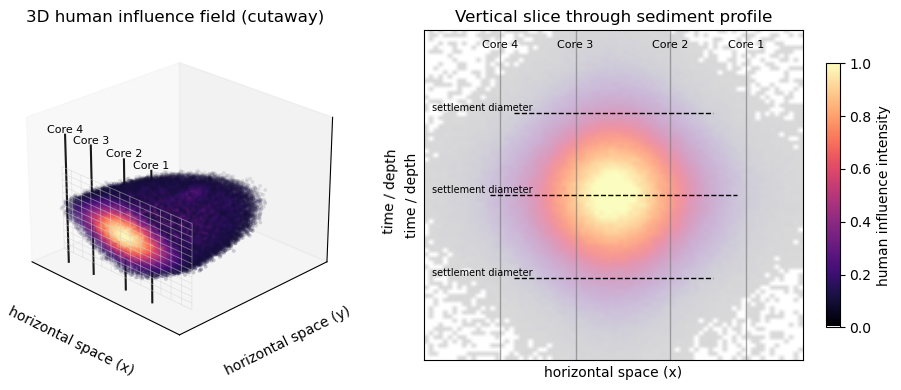

In [2]:
plot_influence_field()